# 02 - Right Keypress

In [142]:
import sys
# Ruta donde está el módulo 'eogtouch'
module_path = r"C:\Users\Ana\Documents\Ing Salud\TFG\codigo"

# Añadir al path si no está ya
if module_path not in sys.path:
    sys.path.append(module_path)


## Rutinas


In [143]:
import pandas as pd
from os.path import expanduser, join, getmtime, isfile
from glob import glob

import matplotlib.pyplot as plt

from eogtouch.models.enums import StimuliColor
from eogtouch.models.config import GREEN_KEYS, BLUE_KEYS
import pygame



plt.rcParams["figure.figsize"] = (20,6)

df = pd.read_parquet("/Users/Ana/20250504_175207.parquet")

# Detectar si hay cambio de color del estímulo entre filas consecutivas
df['stimulus_change'] = df['stimuli_color'].diff().abs() > 0

resultados = []

# Solo itero las filas donde hubo un cambio de color del estímulo
for idx, row in df[df['stimulus_change']].iterrows():
    stimulus_time = row['timestamp']
    stimulus_color = row['stimuli_color']

    if stimulus_color not in [StimuliColor.Green.int_value, StimuliColor.Blue.int_value]: 
        continue

    df_window = df[(df['timestamp'] >= stimulus_time) & (df['timestamp'] <= stimulus_time + 5000)] # creo una ventana de 5 segundos para comprobar la tecla pulsada

    key_row = df_window[df_window["key"] > 0].head(1)
    if not key_row.empty:
        key_pressed = int(key_row["key"].values[0])
        is_correct = False

        if stimulus_color == StimuliColor.Green.int_value:
            is_correct = key_pressed in GREEN_KEYS
        elif stimulus_color == StimuliColor.Blue.int_value:
            is_correct = key_pressed in BLUE_KEYS

        color_enum = StimuliColor.from_int_value(stimulus_color)
        key_name = pygame.key.name(key_pressed)
        result = "bien" if is_correct else "fallo"
        
        
        print(f"StimuliColor: {color_enum.name}  Tecla: {key_name} = {result}")
        response_time = key_row["timestamp"].values[0] - stimulus_time

        resultados.append({
            "stimulus_index": idx,
            "color": color_enum.name,
            "key": key_name,
            "correct": is_correct,
            "response_time_ms": response_time
        })

    else:
        print(f"No se presionó ninguna tecla. Fila: {idx}")
        color_enum = StimuliColor.from_int_value(stimulus_color)
        resultados.append({
            "stimulus_index": idx,
            "color": color_enum.name,
            "key": None,
            "correct": False,
            "response_time_ms": None
        })
        
    df_resultados = pd.DataFrame(resultados)

StimuliColor: Green  Tecla: k = fallo
StimuliColor: Green  Tecla: s = bien
StimuliColor: Green  Tecla: s = bien
StimuliColor: Blue  Tecla: a = fallo
StimuliColor: Blue  Tecla: l = bien
StimuliColor: Green  Tecla: s = bien
StimuliColor: Green  Tecla: w = bien
StimuliColor: Green  Tecla: e = bien
StimuliColor: Green  Tecla: x = bien
StimuliColor: Blue  Tecla: l = bien
StimuliColor: Green  Tecla: w = bien
StimuliColor: Green  Tecla: l = fallo
StimuliColor: Green  Tecla: m = fallo
StimuliColor: Green  Tecla: x = bien
StimuliColor: Green  Tecla: q = bien
StimuliColor: Blue  Tecla:  = fallo
StimuliColor: Blue  Tecla:  = fallo


### Número de pruebas por color

In [144]:
cuenta_colores = df_resultados["color"].value_counts()
print("\nNúmero de pruebas por color:")
# Imprimir resultados sin encabezados ni etiquetas adicionales
print(f"Green: {cuenta_colores.get('Green', 0)}")
print(f"Blue: {cuenta_colores.get('Blue', 0)}")


Número de pruebas por color:
Green: 12
Blue: 5


## Tiempo de respuesta para cada color 


Este es el tiempo transcurrido entre que el estímulo cambia de color (alineación) hasta que se teclea una tecla.  
Se incluyen todos los ejemplos.  
Se mide reacción

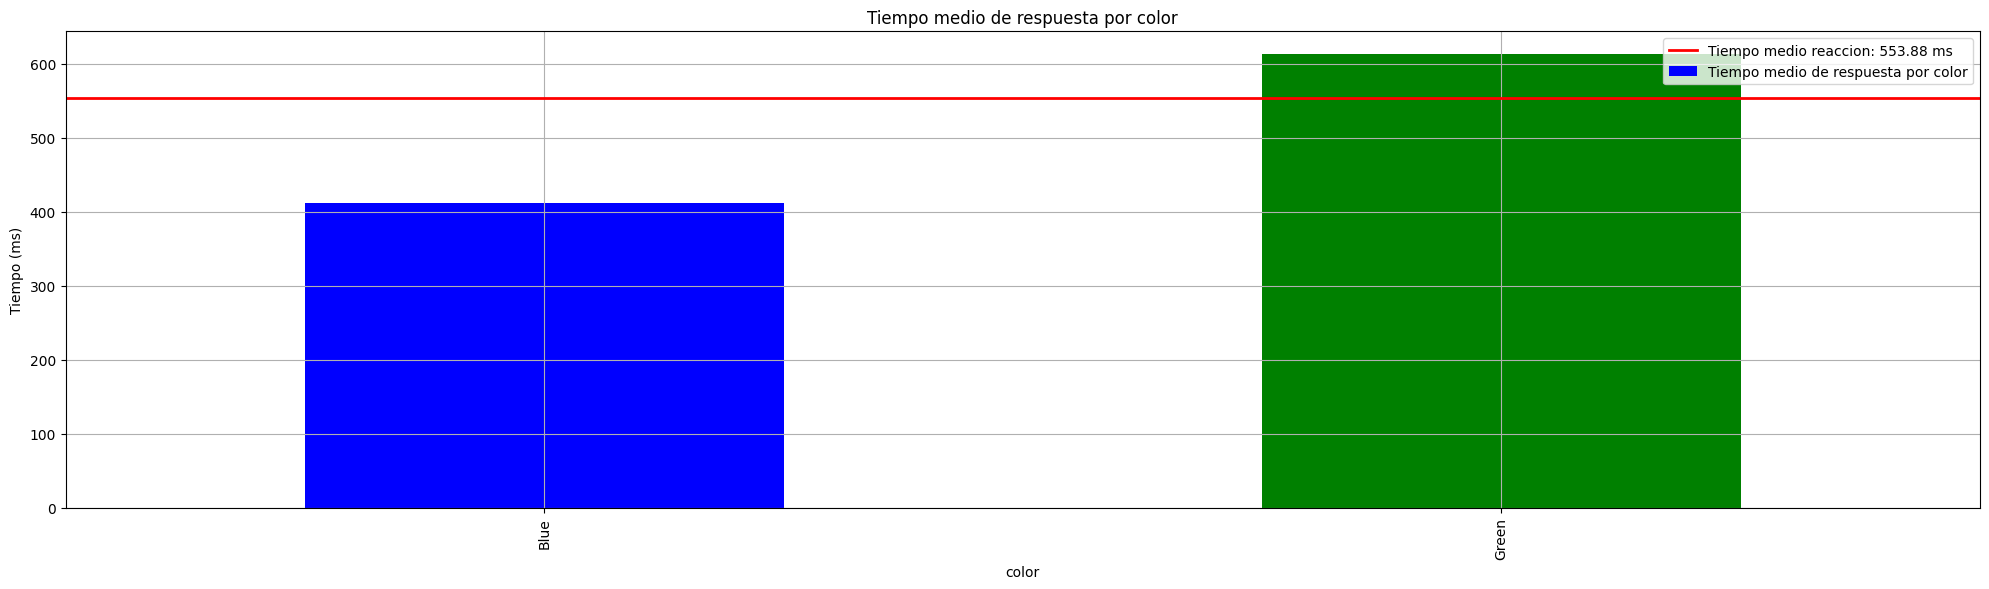

In [145]:
# Filtrar solo las respuestas que tienen tiempo registrado
tiempos = df_resultados[df_resultados["response_time_ms"].notnull()]

# Calcular tiempo medio de respuesta por color
tiempo_medio = tiempos.groupby("color")["response_time_ms"].mean() 


# Calcular el tiempo medio de reacción general
tiempo_medio_general = tiempos["response_time_ms"].mean()

# Crear el gráfico de barras con colores personalizados
color_map = {"Green": "green", "Blue": "blue"}
bar_colors = [color_map[color] for color in tiempo_medio.index]

# Graficar
tiempo_medio.plot(kind="bar", title="Tiempo medio de respuesta por color", color=bar_colors, label= "Tiempo medio de respuesta por color")
plt.axhline(tiempo_medio_general, color="red", linestyle="-", linewidth=2, label=f"Tiempo medio reaccion: {tiempo_medio_general:.2f} ms")
plt.ylabel("Tiempo (ms)")
plt.grid(True)
plt.tight_layout()


# Etiquetas y leyenda
plt.ylabel("Tiempo (ms)")
plt.legend(loc="upper right")  # Puedes cambiar la posición si prefieres otra
plt.grid(True)
plt.tight_layout()
plt.show()



## Precision

La precisión mide qué proporción de veces se respondió correctamente al color, independientemente de si antes hubo errores o repeticiones

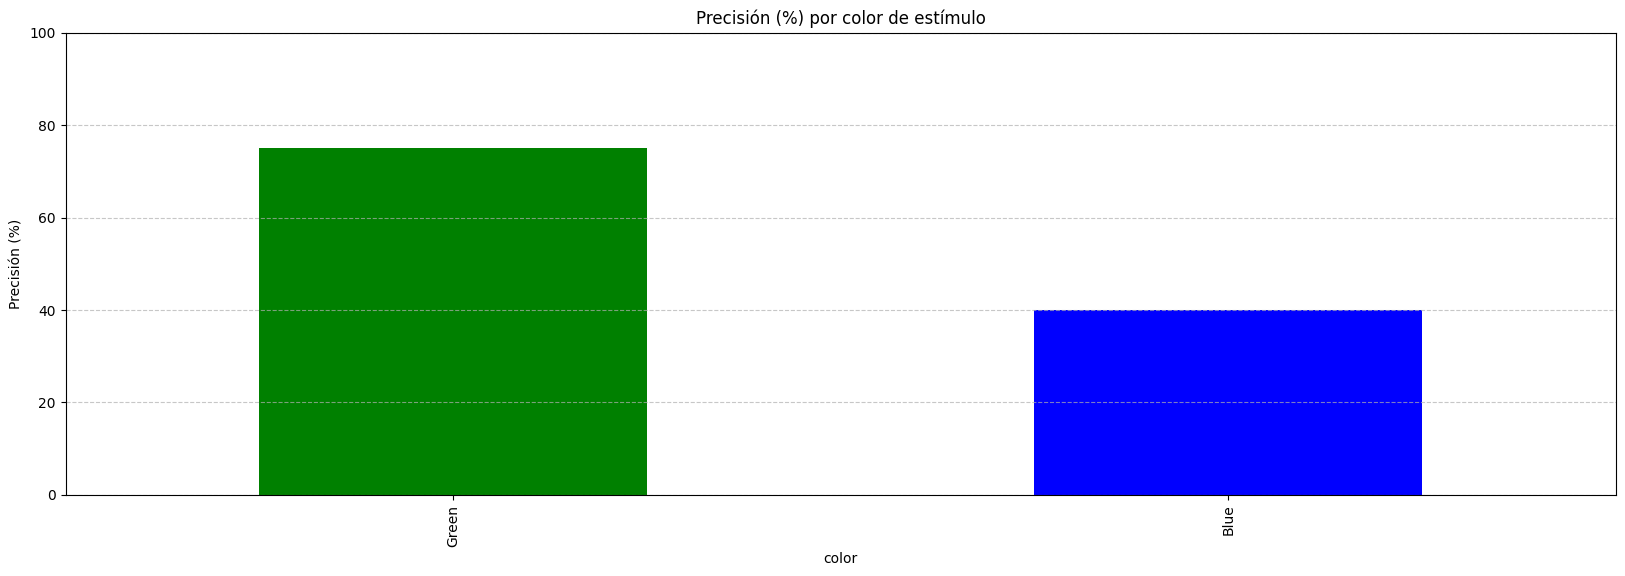

In [146]:
import matplotlib.pyplot as plt

# Agrupa todos los intentos por color (groupby("color")). Calcula la media de la columna "correct" para cada grupo:
# Python interpreta True como 1 y False como 0. 
# Entonces, al hacer .mean(), en realidad estás haciendo: (num aciertos/total resp = (aciertos + errores))*100 -> se cogen todos los resultados

precision_color = df_resultados.groupby("color")["correct"].mean() * 100
precision_color = precision_color.reindex(['Green', 'Blue'])

color_map = {'Green': 'green', 'Blue': 'blue'}
colors = [color_map[c] for c in precision_color.index]

precision_color.plot(kind='bar', color=colors)
plt.title("Precisión (%) por color de estímulo")
plt.ylabel("Precisión (%)")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Precisión (con dato % en grafica)

Mismo código, pero permite representar el dato concreto de % en la gráfica

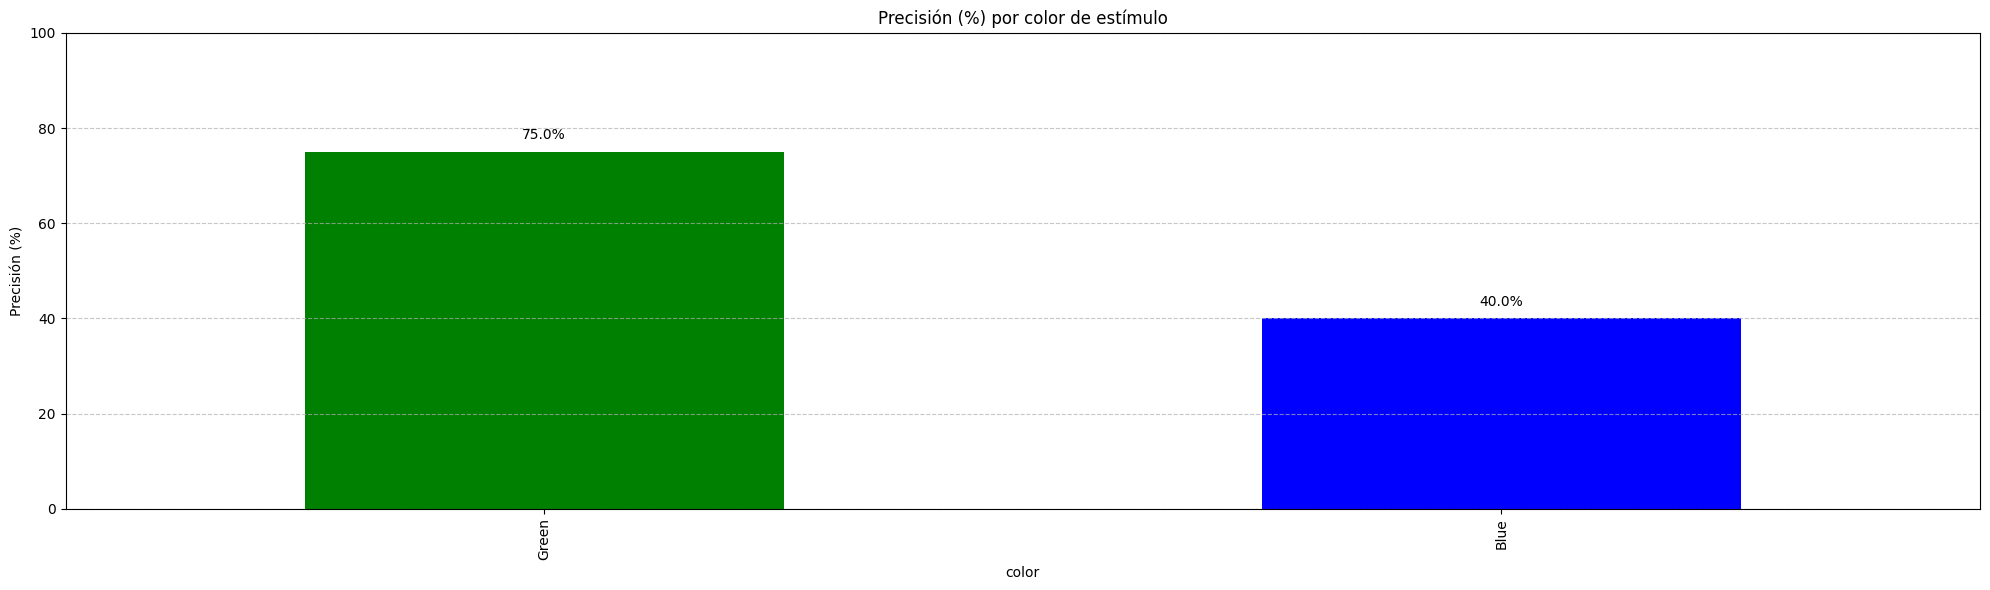

In [147]:
# Crear gráfico
ax = precision_color.plot(kind='bar', color=colors)
plt.title("Precisión (%) por color de estímulo")
plt.ylabel("Precisión (%)")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir valores encima de las barras
for i, value in enumerate(precision_color):
    plt.text(i, value + 2, f"{value:.1f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## Número de errores

Obtiene el número de errores y aciertos por color

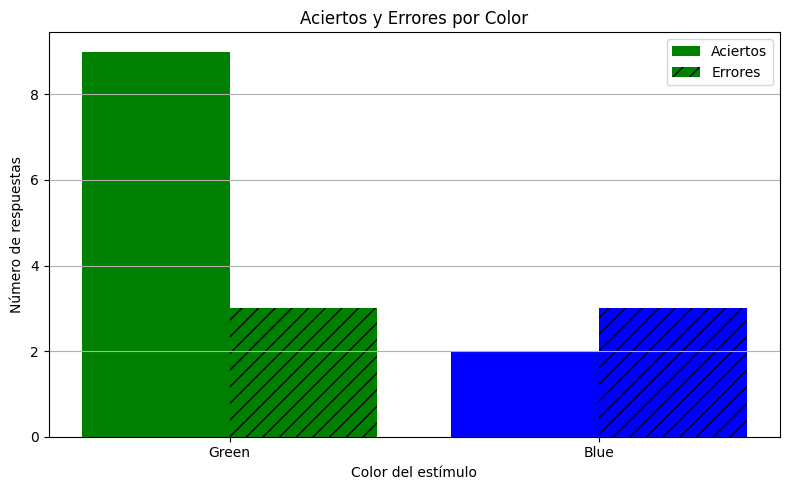

In [148]:
import matplotlib.pyplot as plt
import pandas as pd

# Filtrar aciertos y errores
errores = df_resultados[df_resultados["correct"] == False]
aciertos = df_resultados[df_resultados["correct"] == True]

# Contar por color
errores_por_color = errores["color"].value_counts().reindex(["Green", "Blue"], fill_value=0)
aciertos_por_color = aciertos["color"].value_counts().reindex(["Green", "Blue"], fill_value=0)

# Crear gráfico combinado
colors = ["green", "blue"]
labels = ["Green", "Blue"]
x = range(len(labels))

plt.figure(figsize=(8, 5))

# Aciertos (barra a la izquierda de cada color)
plt.bar([i - 0.2 for i in x], aciertos_por_color, width=0.4, label="Aciertos", color=colors)

# Errores (barra a la derecha de cada color)
plt.bar([i + 0.2 for i in x], errores_por_color, width=0.4, label="Errores", color=colors, hatch='//')

# Personalizar ejes y leyenda
plt.xticks(x, labels)
plt.xlabel("Color del estímulo")
plt.ylabel("Número de respuestas")
plt.title("Aciertos y Errores por Color")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()



## Tiempo de Respuesta y Resultado por Colores

Gráfica comparativa entre el tiempo que el usuario tarda en teclear y si acierta o falla

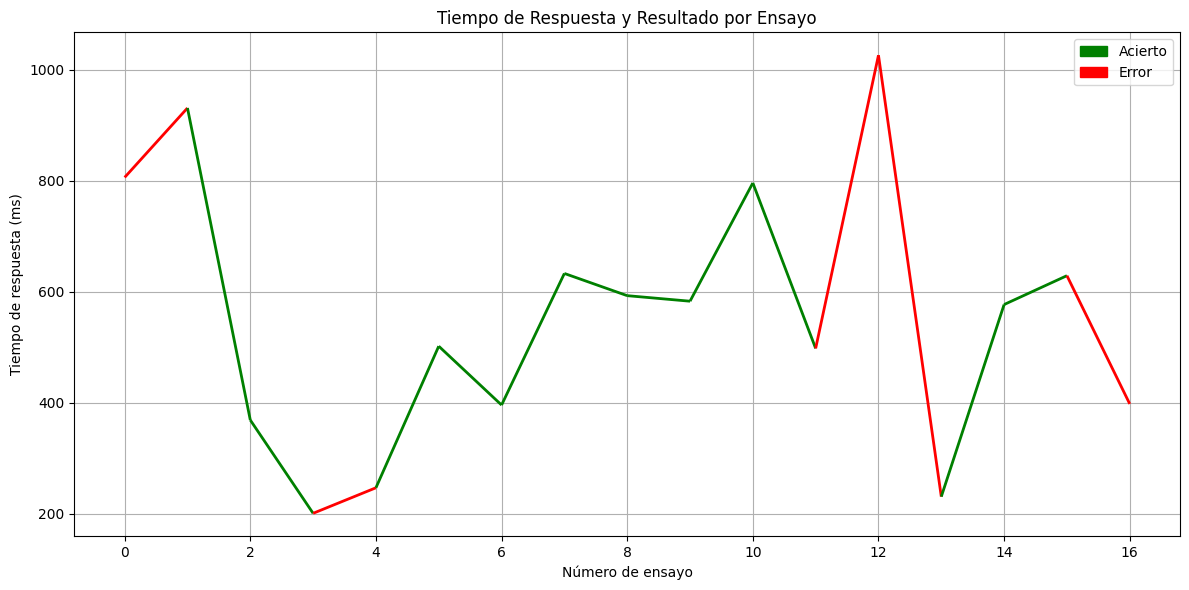

In [149]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches

# Asegúrate de tener los datos filtrados
df_filtrado = df_resultados[df_resultados["response_time_ms"].notnull()].copy()
df_filtrado["correct_int"] = df_filtrado["correct"].astype(int)

# Extraer arrays
x = df_filtrado.index.to_numpy()
y = df_filtrado["response_time_ms"].to_numpy()
correct = df_filtrado["correct"].to_numpy()

# Crear segmentos entre puntos
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Asignar color según si el punto inicial del segmento fue correcto o fallo
# (esto te pinta el segmento entre i e i+1 según si i fue acierto o no)
colors = ['green' if c else 'red' for c in correct[:-1]]

# Crear LineCollection con los segmentos y colores
lc = LineCollection(segments, colors=colors, linewidth=2)

# Dibujar
fig, ax = plt.subplots(figsize=(12, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_title("Tiempo de Respuesta y Resultado por Ensayo")
ax.set_xlabel("Número de ensayo")
ax.set_ylabel("Tiempo de respuesta (ms)")
ax.grid(True)
plt.tight_layout()
ax.grid(True)

# Añadir leyenda personalizada -> con LineCollection, no se crea una "línea" identificable para la leyenda automáticamente (no hay labels),
# como ocurre con plt.plot, hay que crear manualmente los parches de colores
acierto_patch = mpatches.Patch(color='green', label='Acierto')
error_patch = mpatches.Patch(color='red', label='Error')
plt.legend(handles=[acierto_patch, error_patch], loc='upper right')

plt.tight_layout()

plt.show()



# El color se asigna según el punto inicial del segmento. Por ejemplo: 
# Si el índice 5 fue un fallo, y el 6 un acierto, el segmento entre 5 y 6 será rojo.
# Esto ayuda a ver cómo el fallo afecta al tiempo siguiente también.


Correlación de Pearson  -> permite ver si hay causalidad


In [150]:
from scipy.stats import pearsonr

# Asegúrate de trabajar con datos válidos
df_validos = df_resultados[df_resultados["response_time_ms"].notnull()]
df_validos["correct_int"] = df_validos["correct"].astype(int)

# Correlación entre tiempo y acierto
corr, p_value = pearsonr(df_validos["response_time_ms"], df_validos["correct_int"])

print(f"Correlación: {corr:.3f}")
print(f"Valor p: {p_value:.4f}")


for color in ["Green", "Blue"]:
    df_color = df_validos[df_validos["color"] == color]
    corr, p_value = pearsonr(df_color["response_time_ms"], df_color["correct_int"])
    print(f"Color: {color}")
    print(f"  Correlación: {corr:.3f}")
    print(f"  Valor p: {p_value:.4f}")

Correlación: -0.125
Valor p: 0.6338
Color: Green
  Correlación: -0.414
  Valor p: 0.1804
Color: Blue
  Correlación: 0.016
  Valor p: 0.9795


## Código Roberto pintar segmentos por colores

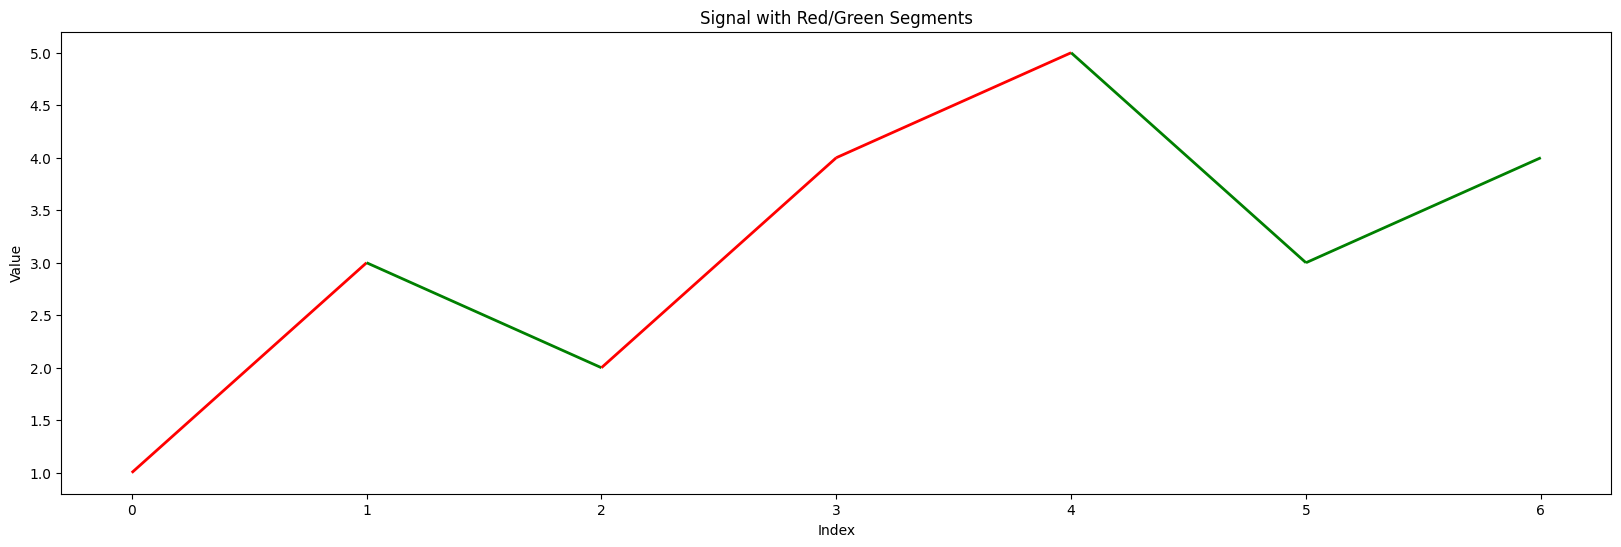

In [151]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# Example data
y = np.array([1, 3, 2, 4, 5, 3, 4])
color_flags = [True, False, True, True, False, False]  # len = len(y) - 1

# x can be index-based
x = np.arange(len(y))

# Prepare segments for LineCollection
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Assign colors based on boolean flags
colors = ['red' if flag else 'green' for flag in color_flags]

# Create LineCollection
lc = LineCollection(segments, colors=colors, linewidth=2)

# Plot
fig, ax = plt.subplots()
ax.add_collection(lc)
ax.autoscale()
ax.set_title("Signal with Red/Green Segments")
ax.set_xlabel("Index")
ax.set_ylabel("Value")
plt.show()